In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\전처리완료_카드(가맹점).csv", encoding='utf-8')
df

,ta_ym,cty_rgn_no,admi_cty_no,blk_cd,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,sale,mm_cnt,mer_cnt,...,open_cnt,stop_cnt,close_cnt,open_11_cnt,open_12_23_cnt,open_24_35_cnt,open_36_47_cnt,open_48_59_cnt,open_60_cnt,mm_cnt_num
0,2023-01-01,41135,41135510,100470,Q13,음식,커피/음료,A,57,1,...,0,1,0,0,0,0,0,1,0,57
1,2023-01-01,41135,41135510,100470,R07,학문/교육,입시학원,A,84,1,...,0,1,0,0,0,0,0,0,1,84
2,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,A,1,1,...,1,0,1,0,0,1,0,0,0,1
3,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,E,32,1,...,0,0,1,0,0,1,0,0,0,32
4,2023-01-01,41135,41135680,101678,O03,여가/오락,일반스포츠,신규,0,1,...,1,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2130066,2025-12-01,41135,41135670,99971,F02,생활서비스,미용서비스,A,6,1,...,0,1,0,1,0,0,0,0,0,6
2130067,2025-12-01,41135,41135670,99971,F06,생활서비스,세탁/가사서비스,A,199,1,...,0,0,0,0,0,0,0,0,1,199
2130068,2025-12-01,41135,41135670,99971,Q03,음식,닭/오리요리,A,166,1,...,0,0,0,0,0,0,0,0,1,166
2130069,2025-12-01,41135,41135670,99986,R03,학문/교육,기타교육,A,12,1,...,0,1,0,0,1,0,0,0,0,12


In [51]:
# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 구명 매핑 (행정동 차트 가독성)
gu_map = {"41135": "분당구", "41133": "수정구", "41131": "중원구"}
df["구명"] = df["cty_rgn_no"].astype(str).map(gu_map)
df["구_행정동"] = df["구명"] + "_" + df["admi_cty_no"].astype(str)

# 매출구간 E 제외 (분석용)
df_eda = df[df["sale"] != "E"].copy()
df_eda["ta_ym"] = pd.to_datetime(df_eda["ta_ym"])

# 원도심(수정구,중원구) / 분당구 분리
df_원도심 = df_eda[df_eda["cty_rgn_no"].astype(str).isin(["41133", "41131"])].copy()
df_분당구 = df_eda[df_eda["cty_rgn_no"].astype(str) == "41135"].copy()

print(f"전체: {len(df):,}행  →  E 제외 후: {len(df_eda):,}행")
print(f"  원도심(수정+중원): {len(df_원도심):,}행")
print(f"  분당구(신도심):    {len(df_분당구):,}행")
print()
print("매출구간 분포 (E 제외):")
print(df_eda["sale"].value_counts())

전체: 2,130,071행  →  E 제외 후: 1,742,211행
  원도심(수정+중원): 898,306행
  분당구(신도심):    843,905행

매출구간 분포 (E 제외):
sale
A     1069467
B      231895
C      214109
D      159267
신규      67473
Name: count, dtype: int64


## 1. 개폐업률 정의

| 지표 | 공식 |
|---|---|
| 개업률 (%) | Σ open_cnt / Σ mer_cnt × 100 |
| 폐업률 (%) | Σ close_cnt / Σ mer_cnt × 100 |

- 집계 단위별로 수량을 **합산한 뒤** 비율을 계산한다 (비율의 평균이 아님)
-  (30억 초과 또는 국세청 미등록) 제외

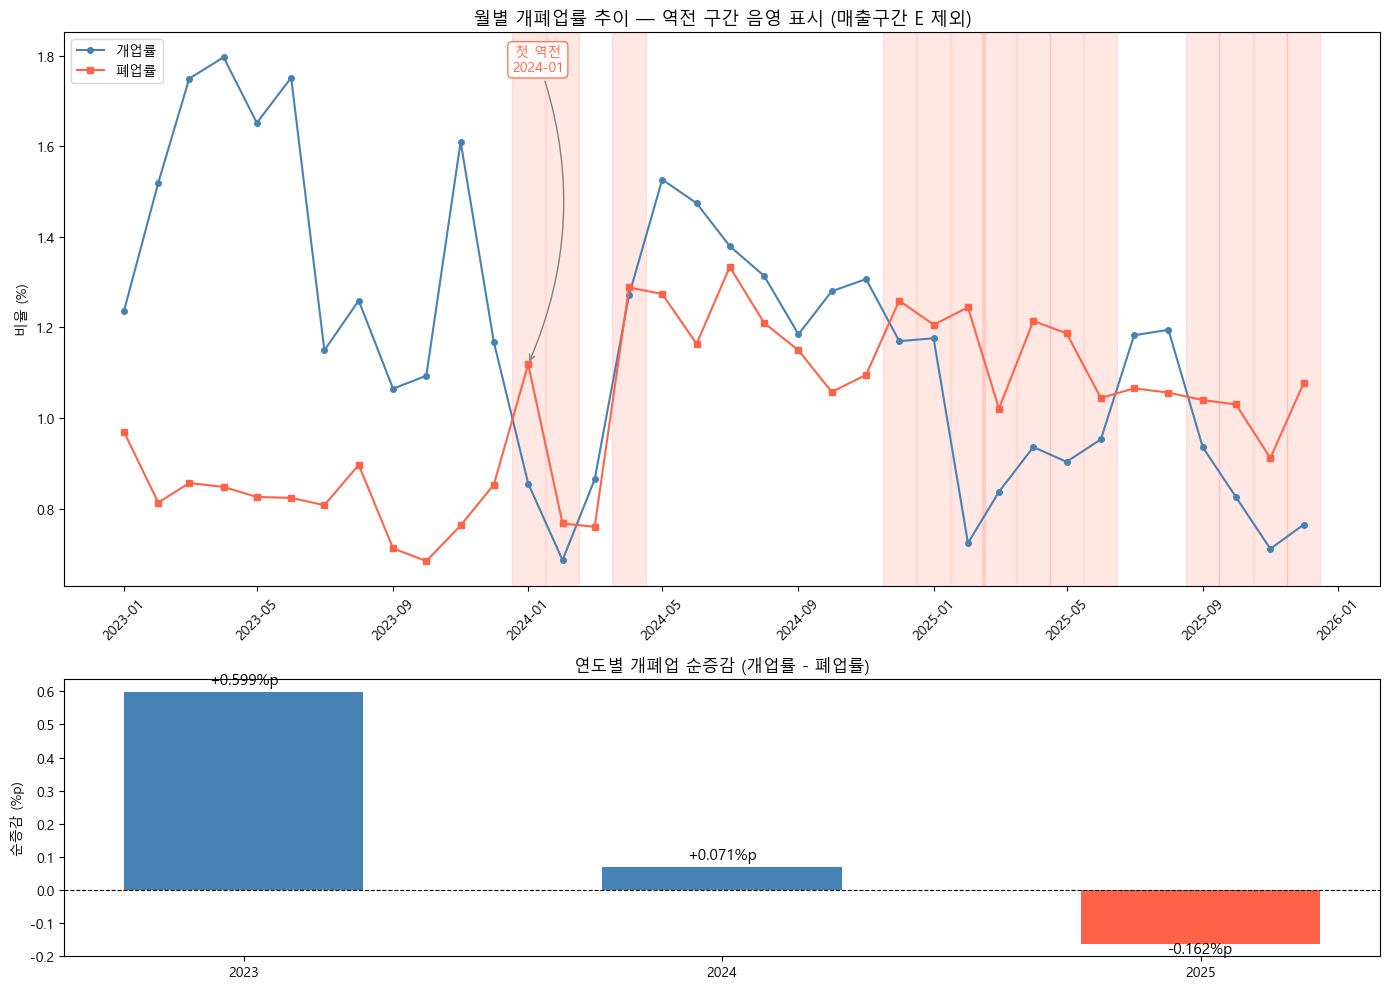

=== 연도별 개폐업률 요약 ===
         개업률    폐업률    순증감
ta_ym                     
2023   1.419  0.821  0.599
2024   1.195  1.124  0.071
2025   0.927  1.090 -0.162

역전 발생: 14개월 / 전체 36개월

=== 역전 구간 목록 (폐업률 > 개업률) ===
  ta_ym      개업률      폐업률       순증감
2024-01 0.855258 1.118608 -0.263349
2024-02 0.686163 0.767186 -0.081023
2024-04 1.270792 1.288183 -0.017391
2024-12 1.169549 1.259055 -0.089506
2025-01 1.176051 1.205779 -0.029728
2025-02 0.723858 1.244204 -0.520346
2025-03 0.837014 1.020501 -0.183486
2025-04 0.935880 1.214209 -0.278329
2025-05 0.903238 1.186947 -0.283709
2025-06 0.952744 1.044088 -0.091343
2025-09 0.935511 1.039578 -0.104067
2025-10 0.825229 1.029850 -0.204621
2025-11 0.711150 0.911616 -0.200466
2025-12 0.764287 1.076352 -0.312065


In [52]:
# ── 구조적 전환점 분석 ───────────────────────────────────────────
# 개업률 < 폐업률 역전 구간을 음영으로 표시하고, 연도별 순증감을 병행 시각화

monthly = (
    df_eda.groupby("ta_ym")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
monthly["개업률"] = monthly["open_cnt"] / monthly["mer_cnt"] * 100
monthly["폐업률"] = monthly["close_cnt"] / monthly["mer_cnt"] * 100

monthly["역전"] = monthly["폐업률"] > monthly["개업률"]
monthly["순증감"] = monthly["개업률"] - monthly["폐업률"]

# 연도별 집계
yearly = (
    df_eda.groupby(df_eda["ta_ym"].dt.year)[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
)
yearly["개업률"] = yearly["open_cnt"] / yearly["mer_cnt"] * 100
yearly["폐업률"] = yearly["close_cnt"] / yearly["mer_cnt"] * 100
yearly["순증감"] = yearly["개업률"] - yearly["폐업률"]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1.5]})

# 상단: 월별 추이 + 역전 구간 음영 ────────────────────────────────────
ax = axes[0]
ax.plot(monthly["ta_ym"], monthly["개업률"], marker="o", ms=4, label="개업률", color="steelblue")
ax.plot(monthly["ta_ym"], monthly["폐업률"], marker="s", ms=4, label="폐업률", color="tomato")

for _, row in monthly[monthly["역전"]].iterrows():
    ax.axvspan(
        row["ta_ym"] - pd.Timedelta(days=15),
        row["ta_ym"] + pd.Timedelta(days=15),
        alpha=0.15, color="tomato",
    )

# 첫 역전 시점 주석 — 텍스트를 axes fraction(차트 상단)에 고정해 데이터와 겹침 방지
first_cross = monthly[monthly["역전"]].iloc[0]["ta_ym"]
y_arrow = monthly.loc[monthly["ta_ym"] == first_cross, "폐업률"].values[0]
ax.annotate(
    f"첫 역전\n{first_cross.strftime('%Y-%m')}",
    xy=(first_cross, y_arrow),
    xycoords="data",
    xytext=(0.36, 0.93),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="gray", connectionstyle="arc3,rad=-0.2"),
    fontsize=10, color="tomato", ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="tomato", alpha=0.85),
)

ax.set_title("월별 개폐업률 추이 — 역전 구간 음영 표시 (매출구간 E 제외)", fontsize=13)
ax.set_ylabel("비율 (%)")
ax.legend()
ax.tick_params(axis="x", rotation=45)

# 하단: 연도별 순증감 막대 ────────────────────────────────────────────
ax2 = axes[1]
bar_colors = ["steelblue" if v >= 0 else "tomato" for v in yearly["순증감"]]
bars = ax2.bar(yearly.index.astype(str), yearly["순증감"], color=bar_colors, width=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, v in zip(bars, yearly["순증감"]):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        v + (0.01 if v >= 0 else -0.04),
        f"{v:+.3f}%p",
        ha="center", va="bottom", fontsize=11,
    )
ax2.set_title("연도별 개폐업 순증감 (개업률 - 폐업률)", fontsize=12)
ax2.set_ylabel("순증감 (%p)")

plt.tight_layout()
plt.show()

# 수치 요약 출력
print("=== 연도별 개폐업률 요약 ===")
print(yearly[["개업률", "폐업률", "순증감"]].round(3).to_string())
print()
n_rev = monthly["역전"].sum()
print(f"역전 발생: {n_rev}개월 / 전체 {len(monthly)}개월")
print()
print("=== 역전 구간 목록 (폐업률 > 개업률) ===")
rev = monthly[monthly["역전"]][["ta_ym", "개업률", "폐업률", "순증감"]].copy()
rev["ta_ym"] = rev["ta_ym"].dt.strftime("%Y-%m")
print(rev.to_string(index=False))

# 그래프 해석

- 2024년 1월에 폐업률이 개업률을 역전한 첫번째 시점
- 전체 36개월중 14개월이 폐업률이 개업률을 상회하는 수치를 보임
- 2025년에는 12개월 중 10개월이 폐업률 우위로, 구조적 감소 국면에 진입함을 알 수 있음

---

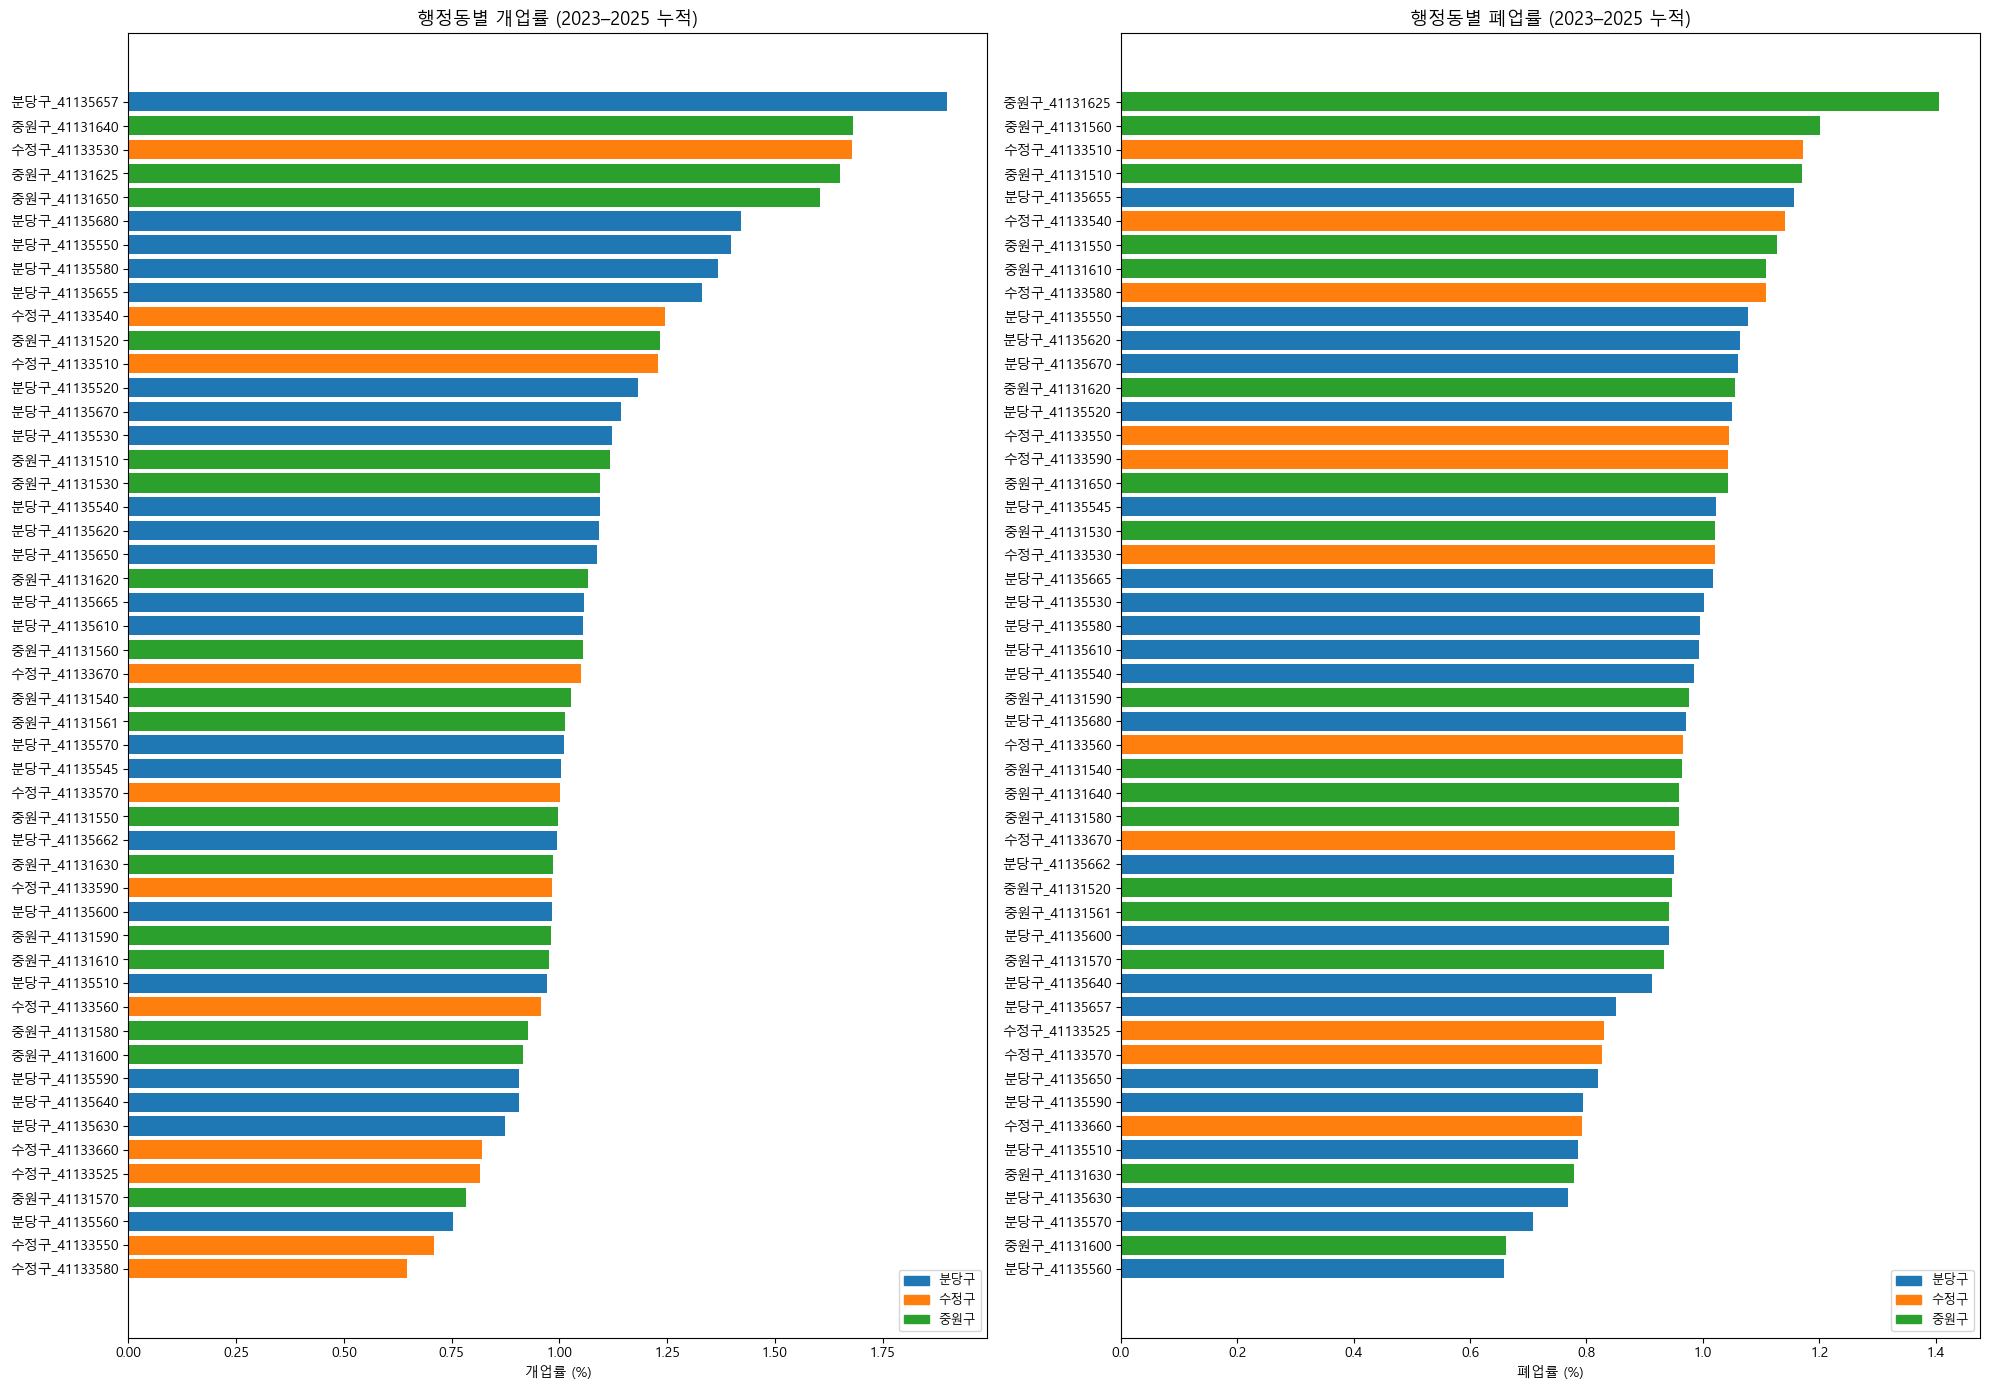

개업률 상위 5 행정동:
       구_행정동      개업률      폐업률
분당구_41135657 1.898202 0.850960
중원구_41131640 1.680176 0.959657
수정구_41133530 1.679766 1.020188
중원구_41131625 1.651286 1.405816
중원구_41131650 1.605207 1.042753

폐업률 상위 5 행정동:
       구_행정동      개업률      폐업률
중원구_41131625 1.651286 1.405816
중원구_41131560 1.054726 1.201493
수정구_41133510 1.228994 1.171784
중원구_41131510 1.116471 1.169637
분당구_41135655 1.331250 1.157052


In [53]:
# ── 행정동별 개폐업률 (전체 기간 합산) ────────────────────────────
dong = (
    df_eda.groupby("구_행정동")[["open_cnt", "close_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
dong["개업률"] = dong["open_cnt"] / dong["mer_cnt"] * 100
dong["폐업률"] = dong["close_cnt"] / dong["mer_cnt"] * 100
dong["순증감"] = dong["개업률"] - dong["폐업률"]
dong["구명"]   = dong["구_행정동"].str.split("_").str[0]

# 구별 색상 구분
color_map = {label: c for label, c in zip(
    dong["구_행정동"].str.split("_").str[0].unique(),
    ["#1f77b4", "#ff7f0e", "#2ca02c"]
)}
bar_colors_open  = dong.sort_values("개업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)
bar_colors_close = dong.sort_values("폐업률", ascending=True)["구_행정동"].str.split("_").str[0].map(color_map)

dong_open  = dong.sort_values("개업률", ascending=True)
dong_close = dong.sort_values("폐업률", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

axes[0].barh(dong_open["구_행정동"], dong_open["개업률"], color=bar_colors_open.values)
axes[0].set_title("행정동별 개업률 (2023–2025 누적)", fontsize=13)
axes[0].set_xlabel("개업률 (%)")

axes[1].barh(dong_close["구_행정동"], dong_close["폐업률"], color=bar_colors_close.values)
axes[1].set_title("행정동별 폐업률 (2023–2025 누적)", fontsize=13)
axes[1].set_xlabel("폐업률 (%)")

# 범례
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=g) for g, c in color_map.items()]
axes[0].legend(handles=legend_patches, loc="lower right", fontsize=9)
axes[1].legend(handles=legend_patches, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

print("개업률 상위 5 행정동:")
print(dong.nlargest(5, "개업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))
print()
print("폐업률 상위 5 행정동:")
print(dong.nlargest(5, "폐업률")[["구_행정동", "개업률", "폐업률"]].to_string(index=False))

## 젠트리피케이션 단계 분류 (개폐업률 기반)

개업률·폐업률을 **중앙값** 기준으로 4사분면에 배치해 단계를 분류합니다.

| 단계 | 개업률 | 폐업률 | 의미 |
|---|---|---|---|
| 안정 | 낮음 | 낮음 | 상권 안정 또는 점진적 공동화 |
| 초기 | 높음 | 낮음 | 외부 자본 유입, 신규 업종 진입 시작 |
| 진행 | 높음 | 높음 | 기존 상인 교체 중 — 상권 불안정 구간 |
| 위험 | 낮음 | 높음 | 신규 유입 고갈 + 기존 상인 이탈 동시 진행 |

In [56]:
# ── 젠트리피케이션 단계 분류 ─────────────────────────────────────────
# 중앙값 기준 4사분면: 개업률↑폐업률↓=초기 / 개업률↑폐업률↑=진행
#                    개업률↓폐업률↑=위험  / 개업률↓폐업률↓=안정

med_open  = dong["개업률"].median()
med_close = dong["폐업률"].median()
def classify_stage(row):
    hi_open  = row["개업률"] >= med_open
    hi_close = row["폐업률"] >= med_close
    if hi_open and not hi_close:
        return "초기"
    elif hi_open and hi_close:
        return "진행"
    elif not hi_open and hi_close:
        return "위험"
    else:
        return "안정"

dong["젠트리피케이션_단계"] = dong.apply(classify_stage, axis=1)

stage_colors = {
    "안정":       "#2ca02c",
    "초기":       "#1f77b4",
    "진행": "#ff7f0e",
    "위험":       "#d62728",
}
stage_order = ["안정", "초기", "진행", "위험"]

print(f"기준 중앙값 — 개업률: {med_open:.3f}%  /  폐업률: {med_close:.3f}%")
print()
print("=== 행정동별 젠트리피케이션 단계 분류 결과 ===")
print(
    dong[["구_행정동", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 (전체) ===")
print(dong["젠트리피케이션_단계"].value_counts()[stage_order].to_string())

# 원도심 위험·진행 단계 별도 출력
dong_원도심_stage = dong[dong["구명"].isin(["수정구", "중원구"])].copy()
print()
print("=== 원도심(수정+중원) 위험/진행 단계 행정동 ===")
risk_dong = dong_원도심_stage[
    dong_원도심_stage["젠트리피케이션_단계"].isin(["위험", "진행"])
]
print(
    risk_dong[["구_행정동", "개업률", "폐업률", "순증감", "젠트리피케이션_단계"]]
    .sort_values(["젠트리피케이션_단계", "순증감"])
    .round(3)
    .to_string(index=False)
)

기준 중앙값 — 개업률: 1.039%  /  폐업률: 0.981%

=== 행정동별 젠트리피케이션 단계 분류 결과 ===
       구_행정동   개업률   폐업률    순증감 젠트리피케이션_단계
중원구_41131570 0.784 0.933 -0.149         안정
중원구_41131580 0.927 0.959 -0.032         안정
수정구_41133525 0.817 0.831 -0.014         안정
수정구_41133560 0.956 0.965 -0.009         안정
분당구_41135640 0.906 0.913 -0.007         안정
중원구_41131590 0.980 0.976  0.003         안정
수정구_41133660 0.820 0.793  0.027         안정
분당구_41135600 0.983 0.942  0.041         안정
분당구_41135662 0.995 0.951  0.044         안정
중원구_41131540 1.028 0.965  0.063         안정
중원구_41131561 1.013 0.943  0.070         안정
분당구_41135560 0.753 0.658  0.095         안정
분당구_41135630 0.874 0.768  0.106         안정
분당구_41135590 0.907 0.794  0.113         안정
수정구_41133570 1.002 0.827  0.175         안정
분당구_41135510 0.972 0.785  0.187         안정
중원구_41131630 0.986 0.778  0.208         안정
중원구_41131600 0.916 0.661  0.255         안정
분당구_41135570 1.012 0.708  0.304         안정
수정구_41133580 0.648 1.108 -0.460         위험
수정구_41133550 0.709 1.045 -0.3

C:\Users\rmstn\AppData\Local\Temp\ipykernel_21924\3885312579.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


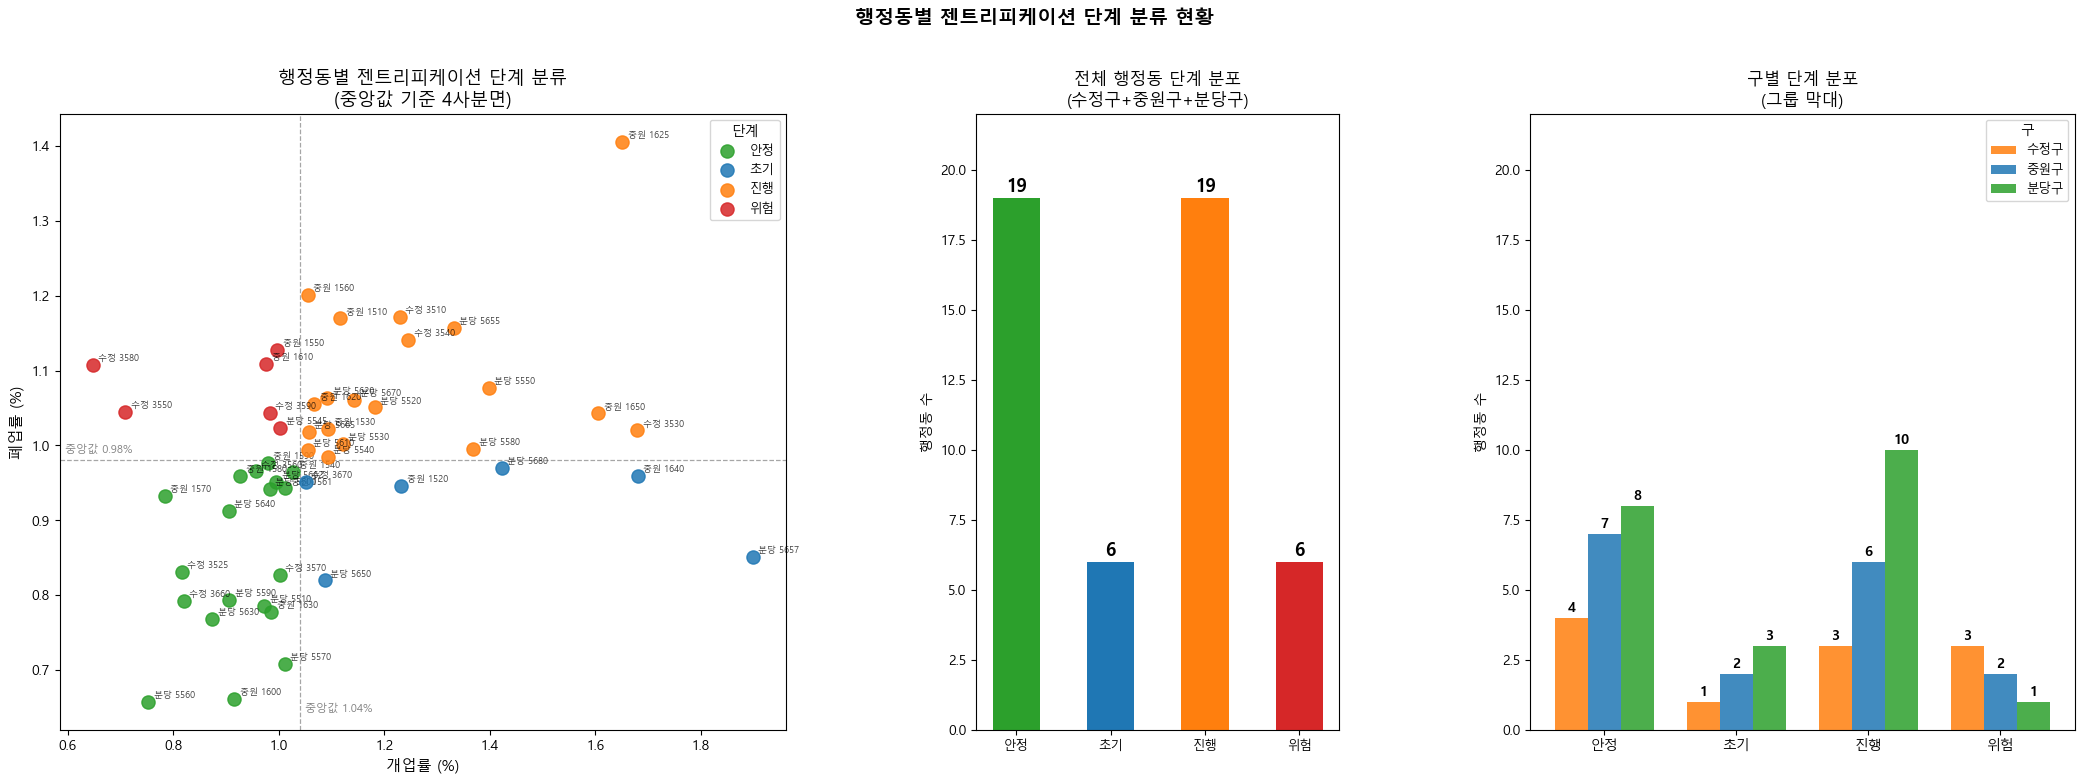

In [57]:
# ── 시각화 ───────────────────────────────────────────────────────────
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(26, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_scatter = fig.add_subplot(gs[0])
ax_total   = fig.add_subplot(gs[1])
ax_gu      = fig.add_subplot(gs[2])

# ── 왼쪽: 개업률 vs 폐업률 산점도 ────────────────────────────────────
for stage in stage_order:
    grp = dong[dong["젠트리피케이션_단계"] == stage]
    ax_scatter.scatter(grp["개업률"], grp["폐업률"],
                       label=stage, color=stage_colors[stage], s=90, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        short = row["구_행정동"].split("_")[0][:2] + " " + row["구_행정동"].split("_")[1][-4:]
        ax_scatter.annotate(short, (row["개업률"], row["폐업률"]),
                            fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_scatter.axvline(med_open,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.axhline(med_close, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_scatter.text(med_open + 0.01, ax_scatter.get_ylim()[0] + 0.02,
                f"중앙값 {med_open:.2f}%", fontsize=8, color="gray", va="bottom")
ax_scatter.text(ax_scatter.get_xlim()[0] + 0.01, med_close + 0.01,
                f"중앙값 {med_close:.2f}%", fontsize=8, color="gray")
ax_scatter.set_xlabel("개업률 (%)", fontsize=11)
ax_scatter.set_ylabel("폐업률 (%)", fontsize=11)
ax_scatter.set_title("행정동별 젠트리피케이션 단계 분류\n(중앙값 기준 4사분면)", fontsize=13)
ax_scatter.legend(title="단계", fontsize=9)

# ── 중간: 전체 행정동 단계 분포 ──────────────────────────────────────
counts_total = [dong["젠트리피케이션_단계"].value_counts().get(s, 0) for s in stage_order]
bars = ax_total.bar(stage_order, counts_total,
                    color=[stage_colors[s] for s in stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_total.text(bar.get_x() + bar.get_width() / 2, v + 0.08, str(v),
                  ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_total.set_ylim(0, max(counts_total) + 3)
ax_total.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_total.set_ylabel("행정동 수")
ax_total.tick_params(axis="x", labelsize=9)

# ── 오른쪽: 구별 단계 분포 (그룹 막대) ───────────────────────────────
gu_list = ["수정구", "중원구", "분당구"]
gu_colors = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}

x = np.arange(len(stage_order))
width = 0.25

for i, gu in enumerate(gu_list):
    counts_gu = [
        dong[(dong["구명"] == gu) & (dong["젠트리피케이션_단계"] == s)].shape[0]
        for s in stage_order
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_colors[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")

ax_gu.set_xticks(x)
ax_gu.set_xticklabels(stage_order, fontsize=10)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("행정동별 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# 그래프 해석

- 위험(개업률은 낮고, 폐업률은 높음)에 해당하는 6개의 행정동 중 5개가 원도심에 해당됨
- 원도심 28개 행정동 중 14개가 위험 혹은 진행 단계임
- 분당구도 진행 단계인 행정동이 10개가 관측됨. 하지만 안정 단계도 그만큼 많은 상황

---

# 2. 프랜차이즈수 변화

기준 중앙값 — 프랜차이즈율: 5.204%  /  기울기: -0.0057

=== 행정동별 프랜차이즈 단계 분류 결과 ===
       구_행정동  프랜차이즈율     기울기 단계
분당구_41135590  4.3807 -0.0268 안정
중원구_41131570  2.8309 -0.0201 안정
중원구_41131580  4.3303 -0.0196 안정
수정구_41133590  4.9886 -0.0167 안정
분당구_41135630  3.8868 -0.0131 안정
수정구_41133510  4.0162 -0.0121 안정
중원구_41131550  4.1040 -0.0117 안정
분당구_41135550  5.2039 -0.0081 안정
분당구_41135545  4.7924 -0.0077 안정
분당구_41135610  4.9950 -0.0074 안정
분당구_41135640  4.6706 -0.0063 안정
중원구_41131640  7.4878 -0.0738 위험
중원구_41131625  7.1784 -0.0570 위험
분당구_41135520  5.7772 -0.0500 위험
분당구_41135650  6.1250 -0.0346 위험
중원구_41131540  5.5293 -0.0284 위험
분당구_41135570  5.6859 -0.0239 위험
수정구_41133540  5.7661 -0.0235 위험
분당구_41135670  5.7047 -0.0202 위험
분당구_41135580  5.5314 -0.0190 위험
분당구_41135540  6.7983 -0.0160 위험
분당구_41135655  6.9953 -0.0157 위험
중원구_41131610  6.1982 -0.0103 위험
중원구_41131510  5.2653 -0.0094 위험
분당구_41135657  5.2045 -0.0085 위험
중원구_41131530  5.4955 -0.0044 진행
분당구_41135620  5.7553 -0.0026 진행
중원구_41131620  5.3177  0.0002 진행
분당

C:\Users\rmstn\AppData\Local\Temp\ipykernel_21924\1133191306.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


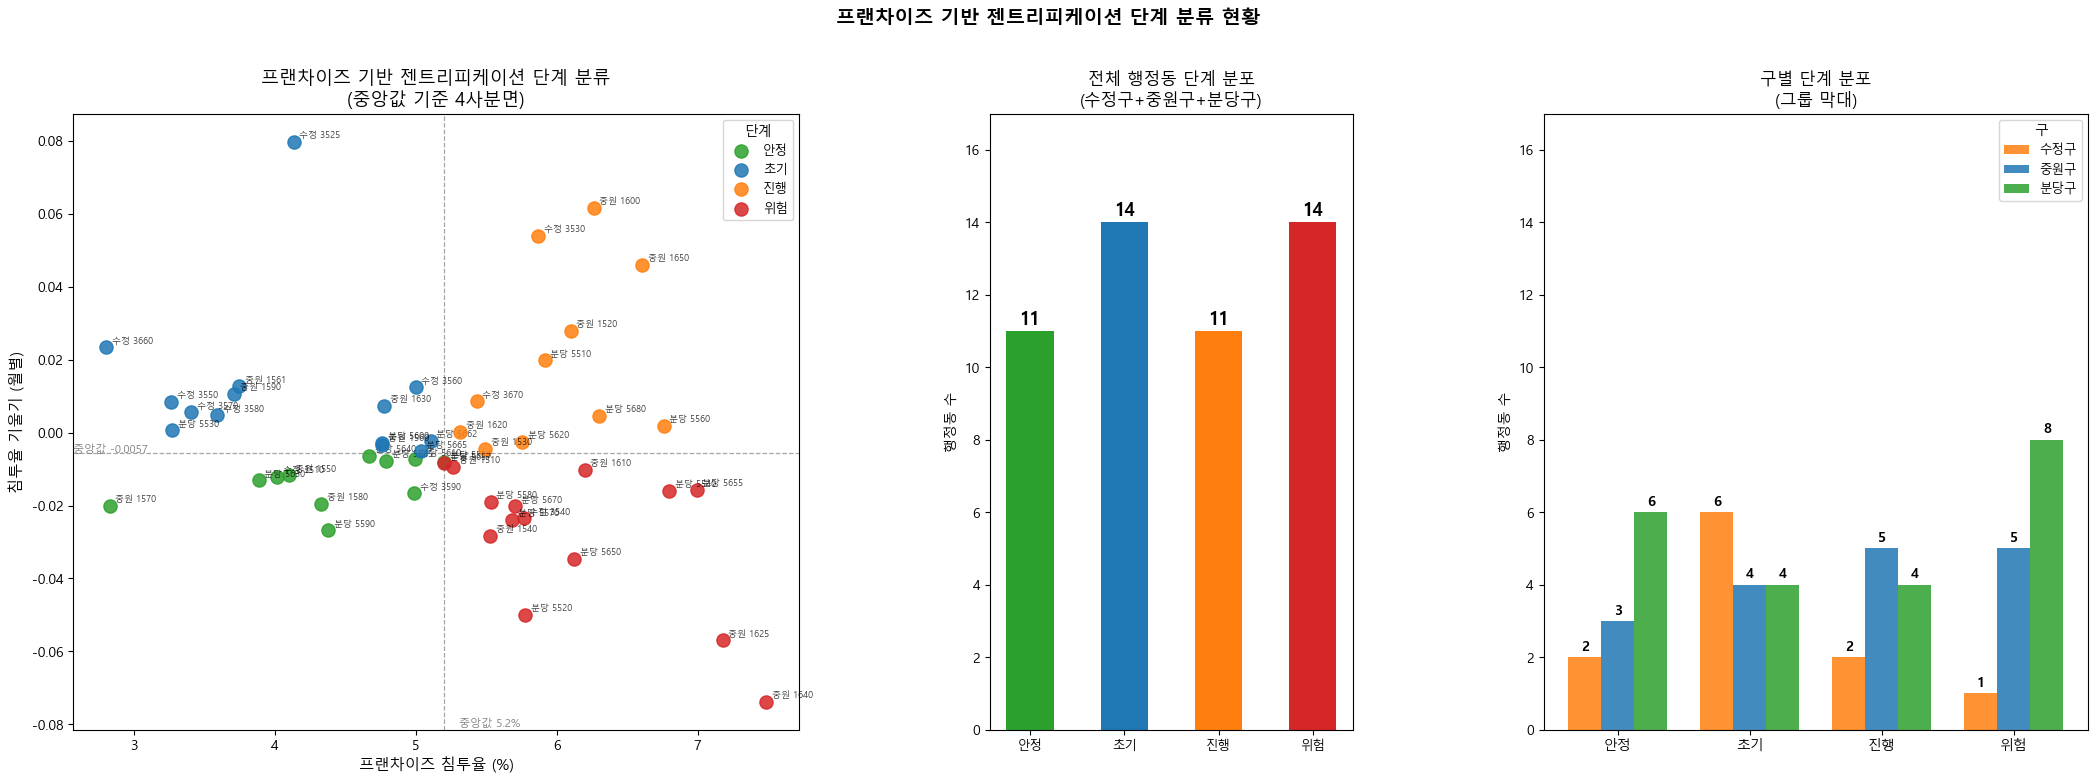

In [59]:
# ── 프랜차이즈 기반 젠트리피케이션 단계 분류 ──────────────────────────
# 축 대응:
#   개업률(새 유입)   ↔ 기울기(침투율 증가 속도)
#   폐업률(기존 이탈) ↔ 침투율(현재 프랜차이즈 비중)
#
# 단계 정의:
#   초기  : 침투율 낮음 + 기울기 높음  → 프랜차이즈 막 진입 시작
#   진행  : 침투율 높음 + 기울기 높음  → 프랜차이즈 빠르게 대체 진행
#   위험  : 침투율 높음 + 기울기 낮음  → 이미 포화, 소상공인 대부분 이탈
#   안정  : 침투율 낮음 + 기울기 낮음  → 프랜차이즈 영향 없음

# 행정동별 누적 침투율 계산
fran_cum = (
    df_eda.groupby("구_행정동")[["fran_cnt", "mer_cnt"]]
    .sum()
    .reset_index()
)
fran_cum["프랜차이즈율"] = fran_cum["fran_cnt"] / fran_cum["mer_cnt"] * 100
fran_cum["구명"] = fran_cum["구_행정동"].str.split("_").str[0]

# slope_df 와 합치기 (앞 셀에서 생성됨)
fran_stage = fran_cum.merge(slope_df, on="구_행정동", how="inner")

# 중앙값 기준 분류
med_fran  = fran_stage["프랜차이즈율"].median()
med_slope = fran_stage["기울기"].median()

def classify_fran_stage(row):
    hi_fran  = row["프랜차이즈율"] >= med_fran
    hi_slope = row["기울기"]       >= med_slope
    if not hi_fran and hi_slope:
        return "초기"
    elif hi_fran and hi_slope:
        return "진행"
    elif hi_fran and not hi_slope:
        return "위험"
    else:
        return "안정"

fran_stage["단계"] = fran_stage.apply(classify_fran_stage, axis=1)

fran_stage_colors = {
    "안정": "#2ca02c",
    "초기": "#1f77b4",
    "진행": "#ff7f0e",
    "위험": "#d62728",
}
fran_stage_order = ["안정", "초기", "진행", "위험"]

print(f"기준 중앙값 — 프랜차이즈율: {med_fran:.3f}%  /  기울기: {med_slope:.4f}")
print()
print("=== 행정동별 프랜차이즈 단계 분류 결과 ===")
print(
    fran_stage[["구_행정동", "프랜차이즈율", "기울기", "단계"]]
    .sort_values(["단계", "기울기"])
    .round(4)
    .to_string(index=False)
)
print()
print("=== 단계별 행정동 수 (전체) ===")
print(fran_stage["단계"].value_counts()[fran_stage_order].to_string())

# ── 시각화 ────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(26, 8))
gs = fig.add_gridspec(1, 3, width_ratios=[2, 1, 1.5], wspace=0.35)
ax_sc  = fig.add_subplot(gs[0])
ax_tot = fig.add_subplot(gs[1])
ax_gu  = fig.add_subplot(gs[2])

# 왼쪽: 산점도 (침투율 vs 기울기)
for stage in fran_stage_order:
    grp = fran_stage[fran_stage["단계"] == stage]
    ax_sc.scatter(grp["프랜차이즈율"], grp["기울기"],
                  label=stage, color=fran_stage_colors[stage], s=90, alpha=0.85, zorder=3)
    for _, row in grp.iterrows():
        short = row["구_행정동"].split("_")[0][:2] + " " + row["구_행정동"].split("_")[1][-4:]
        ax_sc.annotate(short, (row["프랜차이즈율"], row["기울기"]),
                       fontsize=6.5, alpha=0.75, xytext=(4, 3), textcoords="offset points")

ax_sc.axvline(med_fran,  color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.axhline(med_slope, color="gray", linestyle="--", linewidth=0.9, alpha=0.7)
ax_sc.text(med_fran + 0.1, ax_sc.get_ylim()[0], f"중앙값 {med_fran:.1f}%",
           fontsize=8, color="gray", va="bottom")
ax_sc.text(ax_sc.get_xlim()[0], med_slope + 0.0002,
           f"중앙값 {med_slope:.4f}", fontsize=8, color="gray")
ax_sc.set_xlabel("프랜차이즈 침투율 (%)", fontsize=11)
ax_sc.set_ylabel("침투율 기울기 (월별)", fontsize=11)
ax_sc.set_title("프랜차이즈 기반 젠트리피케이션 단계 분류\n(중앙값 기준 4사분면)", fontsize=13)
ax_sc.legend(title="단계", fontsize=9)

# 중간: 전체 분포
counts_total = [fran_stage["단계"].value_counts().get(s, 0) for s in fran_stage_order]
bars = ax_tot.bar(fran_stage_order, counts_total,
                  color=[fran_stage_colors[s] for s in fran_stage_order], width=0.5)
for bar, v in zip(bars, counts_total):
    ax_tot.text(bar.get_x() + bar.get_width() / 2, v + 0.08, str(v),
                ha="center", va="bottom", fontsize=13, fontweight="bold")
ax_tot.set_ylim(0, max(counts_total) + 3)
ax_tot.set_title("전체 행정동 단계 분포\n(수정구+중원구+분당구)", fontsize=12)
ax_tot.set_ylabel("행정동 수")
ax_tot.tick_params(axis="x", labelsize=9)

# 오른쪽: 구별 그룹 막대
gu_list   = ["수정구", "중원구", "분당구"]
gu_colors = {"수정구": "#ff7f0e", "중원구": "#1f77b4", "분당구": "#2ca02c"}
x = np.arange(len(fran_stage_order))
width = 0.25

for i, gu in enumerate(gu_list):
    counts_gu = [
        fran_stage[(fran_stage["구명"] == gu) & (fran_stage["단계"] == s)].shape[0]
        for s in fran_stage_order
    ]
    bars_gu = ax_gu.bar(x + (i - 1) * width, counts_gu,
                        width=width, label=gu, color=gu_colors[gu], alpha=0.85)
    for bar, v in zip(bars_gu, counts_gu):
        if v > 0:
            ax_gu.text(bar.get_x() + bar.get_width() / 2, v + 0.1, str(v),
                       ha="center", va="bottom", fontsize=10, fontweight="bold")

ax_gu.set_xticks(x)
ax_gu.set_xticklabels(fran_stage_order, fontsize=10)
ax_gu.set_title("구별 단계 분포\n(그룹 막대)", fontsize=12)
ax_gu.set_ylabel("행정동 수")
ax_gu.legend(title="구", fontsize=9)
ax_gu.set_ylim(0, max(counts_total) + 3)

plt.suptitle("프랜차이즈 기반 젠트리피케이션 단계 분류 현황", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()